<a href="https://colab.research.google.com/github/gayu-kgna/SIG/blob/main/Day%2011%20collab%20stimulation%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training classifier...
Training complete!
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


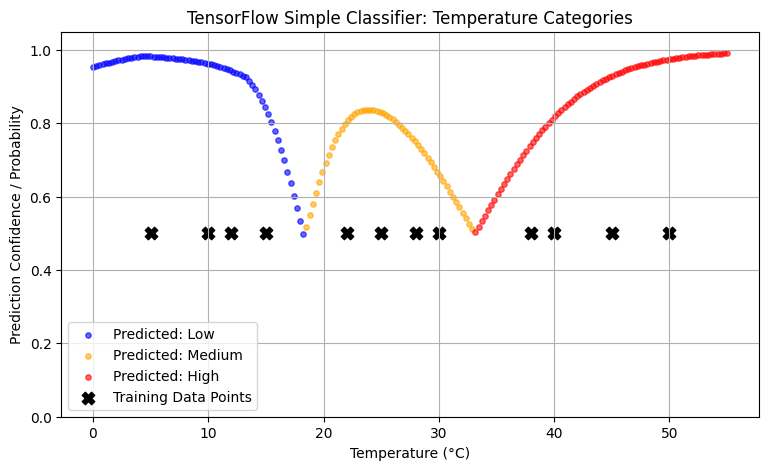

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Temp: 8.0°C -> Class: Low (97.3% confidence)
Temp: 26.0°C -> Class: Medium (81.1% confidence)
Temp: 42.0°C -> Class: High (87.3% confidence)


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Create Labeled Synthetic Dataset
# Features: Temperature readings in °C
X_train = np.array([
    [5.0], [10.0], [12.0], [15.0],   # Low: 0
    [22.0], [25.0], [28.0], [30.0],  # Medium: 1
    [38.0], [40.0], [45.0], [50.0]   # High: 2
], dtype=np.float32)

# Class Labels: 0 = Low (<20°C), 1 = Medium (20°C - 35°C), 2 = High (>35°C)
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2], dtype=np.int32)

# 2. Build Dense Classification Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=8, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(units=8, activation='relu'),
    tf.keras.layers.Dense(units=3, activation='softmax') # 3 output classes
])

# 3. Compile Model
# SparseCategoricalCrossentropy is used for integer class labels (0, 1, 2)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train Model
print("Training classifier...")
history = model.fit(X_train, y_train, epochs=300, verbose=0)
print("Training complete!")

# 5. Generate Test Predictions Across Temperature Range
X_test = np.linspace(0, 55, 200).reshape(-1, 1)
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Map class indices back to labels for display
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

# 6. Plot Decision Boundaries & Test Predictions
plt.figure(figsize=(9, 5))
colors = ['blue', 'orange', 'red']

for class_idx in range(3):
    mask = predicted_classes == class_idx
    plt.scatter(
        X_test[mask],
        np.max(predictions[mask], axis=1),
        c=colors[class_idx],
        label=f'Predicted: {class_labels[class_idx]}',
        alpha=0.6,
        s=15
    )

# Plot training samples on top
plt.scatter(X_train, np.ones_like(X_train) * 0.5, color='black', marker='X', s=80, label='Training Data Points')

plt.title('TensorFlow Simple Classifier: Temperature Categories')
plt.xlabel('Temperature (°C)')
plt.ylabel('Prediction Confidence / Probability')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# Test with new individual readings
sample_temps = np.array([[8.0], [26.0], [42.0]])
sample_preds = model.predict(sample_temps)
for temp, pred in zip(sample_temps, sample_preds):
    predicted_class = class_labels[np.argmax(pred)]
    confidence = np.max(pred) * 100
    print(f"Temp: {temp[0]}°C -> Class: {predicted_class} ({confidence:.1f}% confidence)")